In [1]:
import pandas as pd
import numpy as np
import json
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
np.random.seed(np.random.randint(0, 1000))

products = ["Laptop", "Mouse", "Phone", "TV", "Cables", "Monitor", "Keyboard"]
base_prices = [1200, 25, 800, 1500, 15, 300, 100]

stores = ["London-01", "Paris-05", "NYC-02", "Tokyo-04", "Berlin-03"]

num_rows = 10000
data_list = []

for txn_id in range(num_rows):

    prod_idx = np.random.randint(0, len(products))

    price_noise = np.random.uniform(0.85, 1.15)
    price = round(base_prices[prod_idx] * price_noise, 2)

    qty = np.random.randint(1, 10)

    start_date = pd.to_datetime('2023-01-01')
    random_days = np.random.randint(0, 365)
    txn_date = (start_date + pd.Timedelta(days=random_days)).strftime('%Y-%m-%d')

    store = np.random.choice(stores)

    # inject noise
    if np.random.rand() < 0.01:
        store = None or "UNKNOWN"

    if np.random.rand() < 0.01:
        price = 0

    entry = {
        "transaction_id": txn_id,
        "meta": {"date": txn_date, "store": store},
        "items": [{"prod": products[prod_idx], "qty": qty, "price": price}]
    }

    data_list.append(entry)

In [3]:
# JSON
with open('raw_data.json', 'w') as f:
    json.dump(data_list, f)

# CSV
csv_data = pd.DataFrame([{
    'transaction_id': d['transaction_id'],
    'Date': d['meta']['date'],
    'Store': d['meta']['store'],
    'Product': d['items'][0]['prod'],
    'Quantity': d['items'][0]['qty'],
    'Price': d['items'][0]['price']
} for d in data_list])

csv_data.to_csv('raw_data.csv', index=False)

In [4]:
with open('raw_data.json', 'r') as f:
    raw_json_data = json.load(f)

lake_df = pd.json_normalize(
    raw_json_data,
    record_path=['items'],
    meta=[['meta', 'date'], ['meta', 'store'], 'transaction_id']
)

lake_df.columns = ['Product', 'Quantity', 'Price', 'Date', 'Store', 'TXN_ID']

In [5]:
lake_df['Date'] = pd.to_datetime(lake_df['Date'])
lake_df['Year'] = lake_df['Date'].dt.year
lake_df['Quarter'] = 'Q' + lake_df['Date'].dt.quarter.astype(str)
lake_df['Month'] = lake_df['Date'].dt.month_name()
lake_df['Revenue'] = lake_df['Quantity'] * lake_df['Price']

In [6]:
lake_df = lake_df.dropna(subset=['Store'])
lake_df = lake_df[lake_df['Store'] != 'UNKNOWN']
lake_df = lake_df[lake_df['Price'] > 0]

In [7]:
# Dimension – Time
dim_time = lake_df[['Date', 'Year', 'Quarter', 'Month']].drop_duplicates()

# Fact – Sales
fact_sales = lake_df[['TXN_ID', 'Product', 'Store', 'Date', 'Revenue', 'Quantity']]

In [8]:
slice_laptop = lake_df[lake_df['Product'] == 'Laptop']

In [9]:
dice = lake_df[
    (lake_df['Store'].str.contains('London')) &
    (lake_df['Quarter'] == 'Q1') &
    (lake_df['Product'] == 'Laptop')
]

In [10]:
cube = lake_df.groupby(
    ['Year', 'Quarter', 'Month', 'Store', 'Product']
)['Revenue'].sum()

In [11]:
rollup_quarterly = cube.groupby(
    level=['Year', 'Quarter', 'Store']
).sum()

In [12]:
drilldown_q1 = cube.loc[2023, 'Q1']

In [13]:
pivot_table = lake_df.pivot_table(
    values='Revenue',
    index='Product',
    columns='Store',
    aggfunc='sum',
    fill_value=0
)

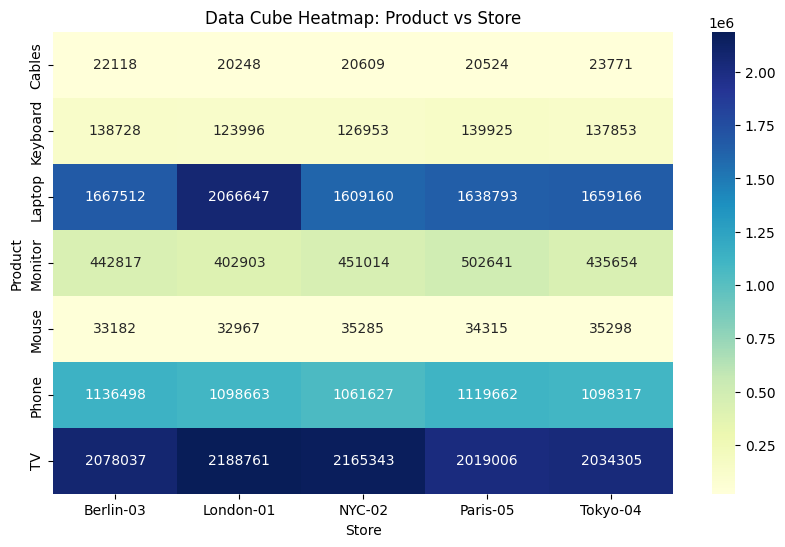

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Data Cube Heatmap: Product vs Store")
plt.show()

In [15]:
total_possible = (
    len(lake_df['Product'].unique()) *
    len(lake_df['Store'].unique()) *
    len(lake_df['Quarter'].unique())
)

actual = len(
    lake_df.groupby(['Product', 'Store', 'Quarter'])
)

sparsity = (1 - actual / total_possible) * 100

print(f"Cube Sparsity: {sparsity:.2f}%")

Cube Sparsity: 0.00%


In [19]:
import plotly.io as pio
pio.renderers.default = 'browser'

store_product = (
    lake_df.dropna(subset=['Store'])
    .query("Store != 'UNKNOWN'")
    .groupby(['Store', 'Product'])['Revenue']
    .sum()
    .reset_index()
)

fig = px.treemap(
    store_product,
    path=['Store', 'Product'],
    values='Revenue',
    color='Revenue',
    color_continuous_scale='RdYlGn',
    title='Treemap: Store → Product Revenue'
)

fig.show()

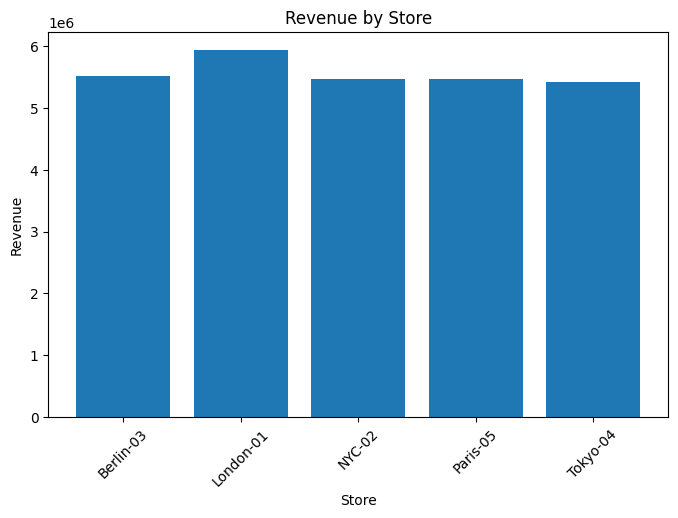

In [20]:
store_rev = lake_df.groupby('Store')['Revenue'].sum().reset_index()

plt.figure(figsize=(8,5))
plt.bar(store_rev['Store'], store_rev['Revenue'])
plt.title("Revenue by Store")
plt.xlabel("Store")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

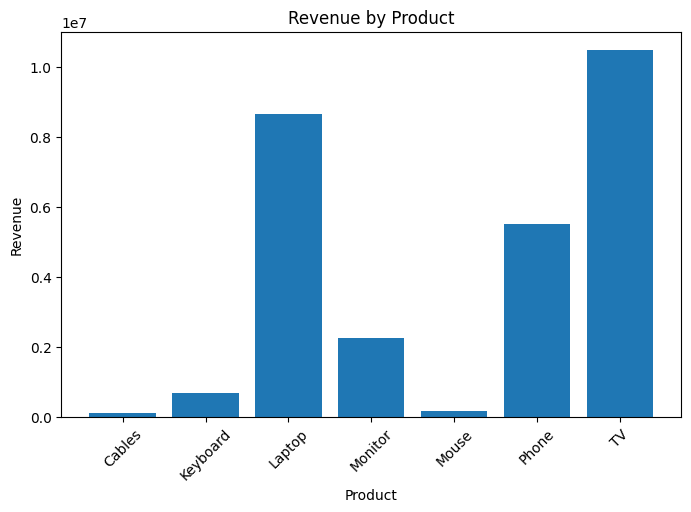

In [21]:
product_rev = lake_df.groupby('Product')['Revenue'].sum().reset_index()

plt.figure(figsize=(8,5))
plt.bar(product_rev['Product'], product_rev['Revenue'])
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()